In [38]:
import random
import numpy as np
from scipy.stats import norm, beta
from scipy.optimize import minimize
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt
from itertools import combinations


# Part 1: Standard MLDS (Maloney & Yang 2003)

We define a true perceptual scale $\psi(s)$, simulate an observer who compares interval differences with additive decision noise, then recover $\psi$ via maximum likelihood.

**Triplet task:** given ordered stimuli $i < j < k$, the observer decides whether $|\psi_i - \psi_j| > |\psi_j - \psi_k|$.

**Decision variable:** $D = |\psi_i - \psi_j| - |\psi_j - \psi_k| + \varepsilon$, where $\varepsilon \sim \mathcal{N}(0, \sigma^2)$.

In [39]:
# --- Setup ---

n_stim = 11
S = np.linspace(0, 1, n_stim)
sigma = 0.1

def rescale(x):
    return (x - x.min()) / (x.max() - x.min())

# True perceptual scale
# def true_psi(s):
#     return 0.5 * (s + beta.cdf(s, 10, 3))

def true_psi(s):
    return beta.cdf(s, 3, 3)

psi_vals = rescale(true_psi(S))

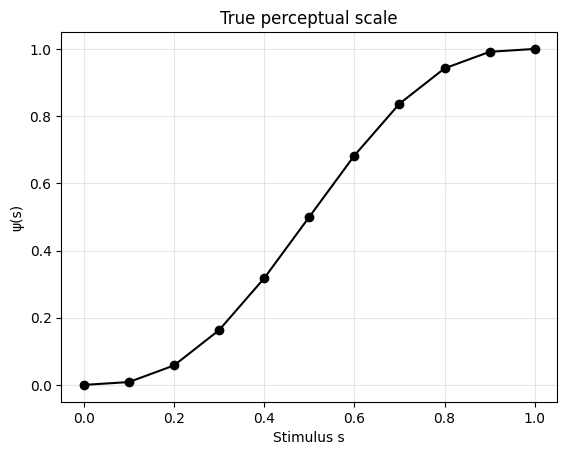

In [40]:
plt.plot(S, psi_vals, 'k-o')
plt.xlabel('Stimulus s')
plt.ylabel('ψ(s)')
plt.title('True perceptual scale')
plt.grid(True, alpha=0.3)
plt.show()

In [41]:

def simulate_trial(i, j, k):
    """Standard MLDS: D = |ψᵢ - ψⱼ| - |ψⱼ - ψₖ| + ε, choice=1 if D>0."""
    d1 = abs(psi_vals[i] - psi_vals[j])
    d2 = abs(psi_vals[j] - psi_vals[k])
    D = (d1 - d2) + np.random.normal(0, sigma)
    return int(D > 0)

n_repeats = 5
indices = list(range(n_stim))
triplets = list(combinations(indices, 3))   # C(11, 3) = 165 unique triplets
data = []

for _ in range(n_repeats):
    for i, j, k in triplets:
        data.append([i, j, k, simulate_trial(i, j, k)])

data = np.array(data)
print(f"{len(triplets)} triplets × {n_repeats} repeats = {len(data)} trials")

165 triplets × 5 repeats = 825 trials


In [ ]:
# --- Fit MLDS ---

def reconstruct_psi(params):
    psi = np.zeros(n_stim)
    psi[0] = 0
    psi[-1] = 1
    psi[1:-1] = params
    return psi

def neg_log_likelihood(params, data):
    psi = reconstruct_psi(params)
    ll = 0
    for row in data:
        i, j, k, choice = int(row[0]), int(row[1]), int(row[2]), row[3]
        d1 = abs(psi[i] - psi[j])
        d2 = abs(psi[j] - psi[k])
        p = np.clip(norm.cdf((d1 - d2) / sigma), 1e-10, 1 - 1e-10)
        ll += choice * np.log(p) + (1 - choice) * np.log(1 - p)
    return -ll

result = minimize(neg_log_likelihood, np.linspace(0, 1, n_stim)[1:-1],
                  args=(data,), method='L-BFGS-B')
psi_hat = reconstruct_psi(result.x)

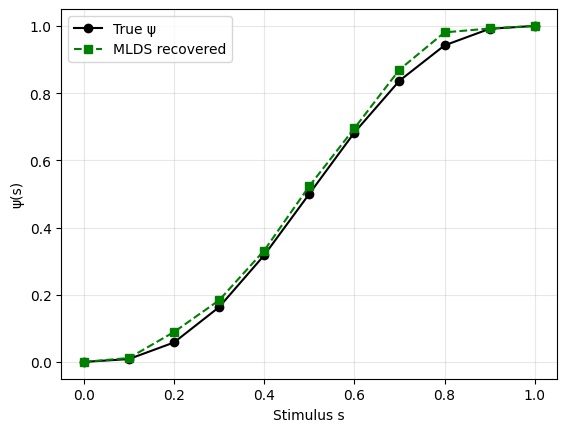

In [ ]:
plt.plot(S, psi_vals, 'k-o', label='True ψ')
plt.plot(S, psi_hat, 'g--s', label='MLDS recovered')
plt.xlabel('Stimulus s')
plt.ylabel('ψ(s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

MLDS recovers the true $\psi$ because the choices were *generated* using `psi_vals`. The fitting procedure never sees $\psi$ directly — it only sees binary choices — but it finds the scale values that make those choices most probable, which converges to the true values.

# Part 2: Bayesian observer

Now the observer is Bayesian. The pipeline changes:

1. **Encode:** $r = \psi(s) + \text{noise}$ (noisy internal measurement)
2. **Decode:** compute posterior = likelihood × prior, take posterior mean

The percept $\hat{s}$ is now *random on every trial* (not a fixed scale + decision noise). It also has a **bias** $b(s) = E[\hat{s}] - s$ from the prior pulling estimates toward high-density regions.

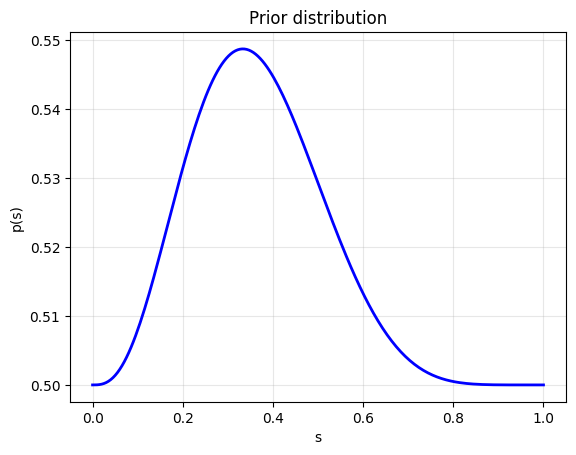

In [ ]:
# --- Prior (related to true_psi: psi is the CDF-like transform) ---

# def prior(s):
#     return 0.5 + 0.5*(beta.pdf(s, 2, 5))

def prior(s):
    smooth = s**2 * (1 - s)**2
    return 0.5 + 0.5 * beta.pdf(s, 2, 5) * smooth

S_grid = np.linspace(0, 1, 200)

plt.plot(S_grid, prior(S_grid), 'b-', lw=2)
plt.xlabel('s')
plt.ylabel('p(s)')
plt.title('Prior distribution')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- Bayesian observer: joint posterior from n_obs independent measurements ---

def bayesian_percept(s, n_obs=1):
    """
    Draw n_obs independent measurements r_i ~ N(ψ(s), σ²),
    form the joint posterior p(s | r_1,...,r_n) ∝ ∏_i p(r_i|s) · p(s),
    return the posterior mean E[s | r_1,...,r_n].
    """
    s_safe = np.clip(s, 0.01, 0.99)
    r_samples = true_psi(s_safe) + np.random.normal(0, sigma, n_obs)
    log_lik = np.sum(
        norm.logpdf(r_samples[:, None], true_psi(S_grid)[None, :], sigma),
        axis=0
    )
    log_lik -= log_lik.max()
    posterior = np.exp(log_lik) * prior(S_grid)
    posterior /= trapezoid(posterior, S_grid)
    return trapezoid(S_grid * posterior, S_grid)

In [ ]:
# --- Expected percept: two methods ---
# (A) Averaging individual single-observation posteriors — estimates E_r[E[s|r]]
# (B) Joint posterior from n_obs measurements — estimates E[E[s|r_1,...,r_n]]

# (A) MC averaging, N = 2000
n_mc = 2000
expected_percept_avg = np.zeros(n_stim)
percept_var_avg      = np.zeros(n_stim)
for idx, s in enumerate(S):
    samples = [bayesian_percept(s, n_obs=1) for _ in range(n_mc)]
    expected_percept_avg[idx] = np.mean(samples)
    percept_var_avg[idx]      = np.var(samples)

# (B) Joint posterior for several n_obs, averaged over 100 trials
n_mc_joint = 1
n_obs_list = [5, 20, 100, 2000]
expected_percept_joint = {}
for n_obs in n_obs_list:
    ep = np.zeros(n_stim)
    for idx, s in enumerate(S):
        ep[idx] = np.mean([bayesian_percept(s, n_obs) for _ in range(n_mc_joint)])
    expected_percept_joint[n_obs] = ep

# --- Rescale to [0, 1] for plotting on the same axis as ψ ---
expected_percept_avg_rs   = rescale(expected_percept_avg)
expected_percept_joint_rs = {n: rescale(ep) for n, ep in expected_percept_joint.items()}

bias = expected_percept_avg - S
print('done')

done


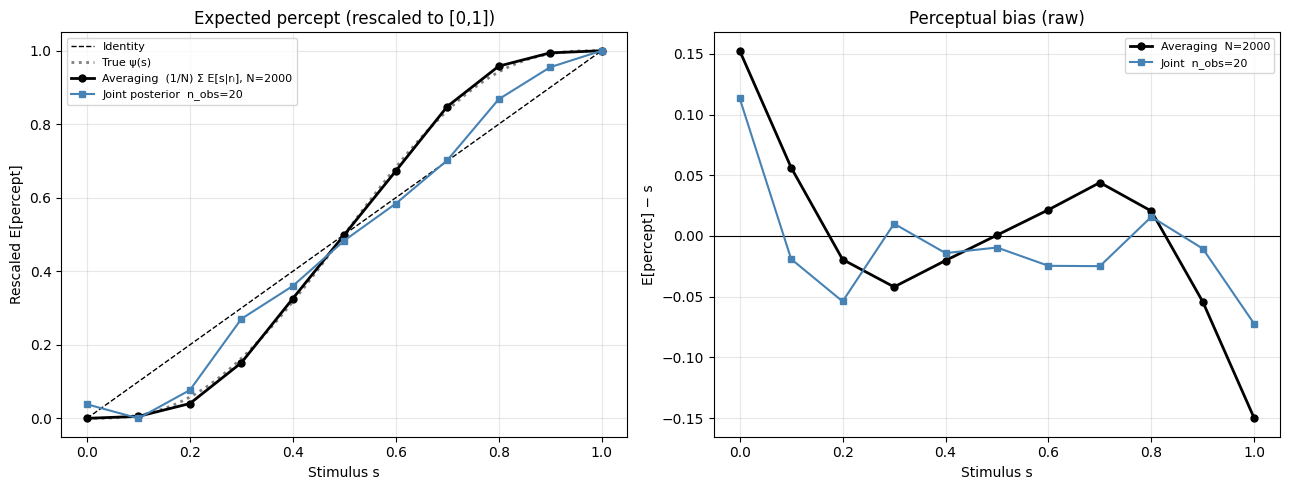

In [ ]:
# --- Compare averaging vs joint posterior (rescaled) ---

colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: rescaled expected percept
axes[0].plot(S, S, 'k--', lw=1, label='Identity')
axes[0].plot(S_grid, rescale(true_psi(S_grid)), 'gray', lw=2, ls=':', label='True ψ(s)')
axes[0].plot(S, expected_percept_avg_rs, 'k-o', ms=5, lw=2,
             label='Averaging  (1/N) Σ E[s|rᵢ], N=2000')
for (n_obs, ep), c in zip(expected_percept_joint_rs.items(), colors):
    axes[0].plot(S, ep, '-s', color=c, ms=5, label=f'Joint posterior  n_obs={n_obs}')
axes[0].set_xlabel('Stimulus s'); axes[0].set_ylabel('Rescaled E[percept]')
axes[0].set_title('Expected percept (rescaled to [0,1])'); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: bias (raw, not rescaled — bias is meaningful only on the original scale)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].plot(S, expected_percept_avg - S, 'k-o', ms=5, lw=2,
             label='Averaging  N=2000')
for (n_obs, ep), c in zip(expected_percept_joint.items(), colors):
    axes[1].plot(S, ep - S, '-s', color=c, ms=5, label=f'Joint  n_obs={n_obs}')
axes[1].set_xlabel('Stimulus s'); axes[1].set_ylabel('E[percept] − s')
axes[1].set_title('Perceptual bias (raw)'); axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

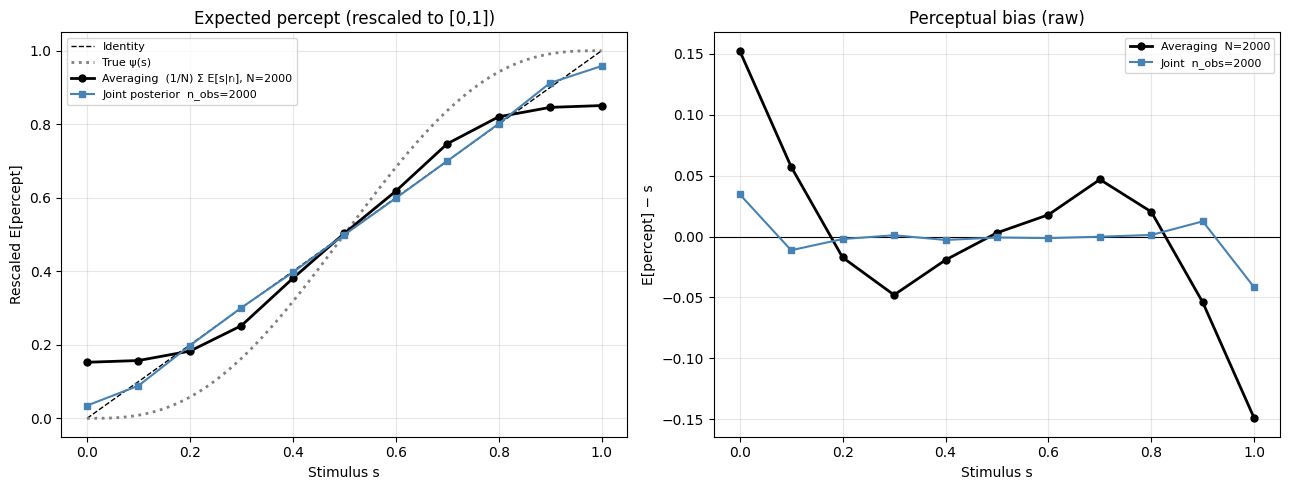

In [ ]:
# --- Compare averaging vs joint posterior (rescaled) ---

colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: rescaled expected percept
axes[0].plot(S, S, 'k--', lw=1, label='Identity')
axes[0].plot(S_grid, rescale(true_psi(S_grid)), 'gray', lw=2, ls=':', label='True ψ(s)')
axes[0].plot(S, expected_percept_avg, 'k-o', ms=5, lw=2,
             label='Averaging  (1/N) Σ E[s|rᵢ], N=2000')
for (n_obs, ep), c in zip(expected_percept_joint.items(), colors):
    axes[0].plot(S, ep, '-s', color=c, ms=5, label=f'Joint posterior  n_obs={n_obs}')
axes[0].set_xlabel('Stimulus s'); axes[0].set_ylabel('Rescaled E[percept]')
axes[0].set_title('Expected percept (rescaled to [0,1])'); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: bias (raw, not rescaled — bias is meaningful only on the original scale)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].plot(S, expected_percept_avg - S, 'k-o', ms=5, lw=2,
             label='Averaging  N=2000')
for (n_obs, ep), c in zip(expected_percept_joint.items(), colors):
    axes[1].plot(S, ep - S, '-s', color=c, ms=5, label=f'Joint  n_obs={n_obs}')
axes[1].set_xlabel('Stimulus s'); axes[1].set_ylabel('E[percept] − s')
axes[1].set_title('Perceptual bias (raw)'); axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

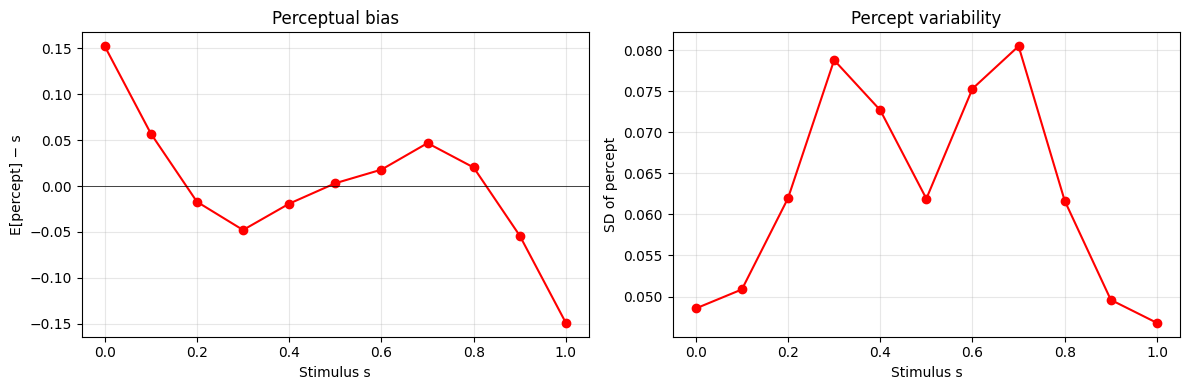

In [ ]:
# --- Bias and variability (from averaging method) ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(S, bias, 'ro-')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('Stimulus s'); axes[0].set_ylabel('E[percept] − s')
axes[0].set_title('Perceptual bias'); axes[0].grid(True, alpha=0.3)

axes[1].plot(S, np.sqrt(percept_var_avg), 'ro-')
axes[1].set_xlabel('Stimulus s'); axes[1].set_ylabel('SD of percept')
axes[1].set_title('Percept variability'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Part 3: Recover ψ from the Bayesian observer

Now we have two ways to read out a scale from the Bayesian observer:

1. **Direct recovery**: the expected percept $E[\hat{s}(s)]$ from Part 2 — the Bayesian model itself gives a mapping $s \mapsto \hat{s}$.
2. **MLDS on Bayesian data**: let the Bayesian observer perform the triplet task, then fit MLDS to its choices.

At the end we compare three ψ estimates:
- MLDS from MLDS-generated data (Part 1)
- Expected percept from the Bayesian observer
- MLDS from Bayesian-observer data

In [ ]:
# --- Simulate Bayesian observer on the MLDS triplet task ---

def simulate_trial_bayes(i, j, k):
    """Each stimulus → independent noisy percept; compare interval magnitudes."""
    m1 = bayesian_percept(S[i])
    m2 = bayesian_percept(S[j])
    m3 = bayesian_percept(S[k])
    return int(abs(m1 - m2) > abs(m2 - m3))

data_bayes = []
for _ in range(n_repeats):
    for i, j, k in triplets:
        data_bayes.append([i, j, k, simulate_trial_bayes(i, j, k)])
data_bayes = np.array(data_bayes)
print(f"{len(triplets)} triplets × {n_repeats} repeats = {len(data_bayes)} trials")

165 triplets × 5 repeats = 825 trials


In [ ]:
# --- Fit MLDS to the Bayesian observer's choices ---

result_bayes = minimize(neg_log_likelihood, np.linspace(0, 1, n_stim)[1:-1],
                        args=(data_bayes,), method='L-BFGS-B')
psi_hat_bayes = reconstruct_psi(result_bayes.x)

In [ ]:
# --- Compare all three recoveries ---

psi_from_avg   = rescale(expected_percept_avg)   # direct Bayesian readout
psi_from_joint = rescale(expected_percept_joint[5])


plt.figure(figsize=(8, 6))
plt.plot(S_grid, rescale(true_psi(S_grid)), 'gray', lw=2, ls=':', label='True ψ(s)')
plt.plot(S, psi_hat,        'g--s', ms=6, label='MLDS on MLDS data (Part 1)')
plt.plot(S, psi_from_avg,   'b-^',  ms=6, label='Expected percept (Bayesian, direct)')
plt.plot(S, psi_from_joint, 'm-+',  ms=6, label='Expected percept (Joint posterior)')
plt.plot(S, psi_hat_bayes,  'r--D', ms=6, label='MLDS on Bayesian-observer data')
plt.xlabel('Stimulus s'); plt.ylabel('Recovered scale (normalized)')
plt.title('Three recoveries of ψ')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

KeyError: 5